## K-Means + umap

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib

import numpy as np
import os

from sklearn.cluster import KMeans

from src.colors import colors_new_legend

In [2]:
variables_path = "data/variables"
figures_path = "data/fi## Import datagures"
berenslab_data_path = "data/embeddings"

In [3]:
pubmed_ids = np.load(os.path.join(berenslab_data_path, "pubmed_ids_umap.npy"))
article_dates = np.load(os.path.join(berenslab_data_path, "article_dates_umap.npy"))
umap_embeddings = np.load(os.path.join(variables_path, "umap_reparsed.npy"))

In [4]:
kmeans = KMeans(
    n_clusters=38,
    init="k-means++",
    n_init="auto",
    max_iter=300,
    random_state=0,
).fit(umap_embeddings)

In [5]:
labels = kmeans.labels_

colors = [colors_new_legend[i] for i in labels]

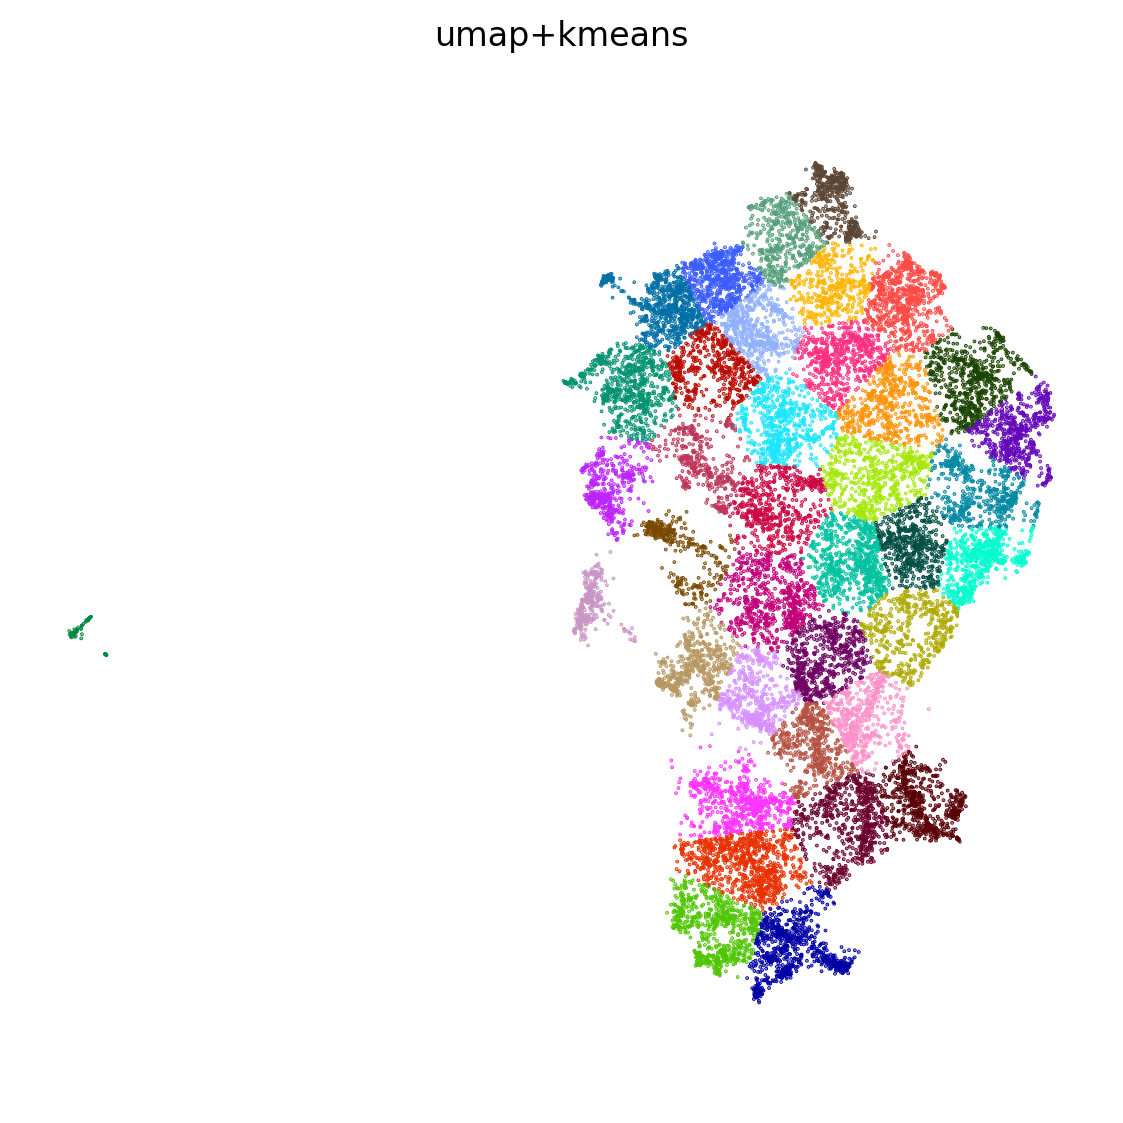

In [6]:
%matplotlib inline

# tsne = tsne
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=200, layout="constrained")

ax.scatter(
    umap_embeddings[:, 0],
    umap_embeddings[:, 1],
    s=0.5,
    c=colors,
    marker=".",
)
ax.set_title("umap+kmeans")
ax.axis("equal")
ax.grid()
ax.axis("off")
plt.show()

fig.savefig('data/results/umap-kmeans.png')